# SO(n): train JacNet (cheap tangent-projection estimator)

This notebook trains a small `JacNet` to predict the
score's Jacobian directly.
`M_tilde(x_t,t) ~= sigma_t^2 * dS/dx_t` (rescaled score Jacobian). Loss: `||M_tilde + eps_hat eps_hat^T + I -
eps eps^T||^2`, weighted by `w(t)=(1-t)`. Recovery at inference: `M = M_tilde / sigma_t^2`.

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.autograd.functional import jacobian as torch_jacobian

SO_N = int(os.environ.get("SO_N", 2))
N_DATA = int(os.environ.get("N_DATA", 10))
CKPT_DIR = f"checkpoints/n{SO_N}_N{N_DATA}"   # same folder 01_train_score.ipynb saved score.pt into

ckpt = torch.load(f"{CKPT_DIR}/score.pt", weights_only=False)
score_config = ckpt["config"]
n, d, device = score_config["n"], score_config["d"], score_config["device"]
X_target = ckpt["X_target"].to(device)

jac_config = {
    "jac_hidden": 256, "jac_depth": 4, "batch": 512, "lr": 2e-4,
    "iters": 30000, "seed": 1,
    "t_skew_power": 3.0,
    "loss_weight_clip": 1000.0,
}
torch.manual_seed(jac_config["seed"])
print(f"n={n}, d={d}, device={device}, ckpt_dir={CKPT_DIR}")

n=2, d=4, device=cpu, ckpt_dir=checkpoints/n2_N5


In [2]:
def beta(t):
    return score_config["beta_min"] + t * (score_config["beta_max"] - score_config["beta_min"])

def alpha_bar(t):
    return torch.exp(-(score_config["beta_min"] * t + 0.5 * (score_config["beta_max"] - score_config["beta_min"]) * t ** 2))

def sigma2(t):
    return (1.0 - alpha_bar(t)).clamp(min=1e-6)

def q_sample(x0, t):
    eps = torch.randn_like(x0)
    a = alpha_bar(t)[:, None]
    return a.sqrt() * x0 + sigma2(t).sqrt()[:, None] * eps, eps

In [3]:
class ScoreNet(nn.Module):
    def __init__(self, d, hidden, depth):
        super().__init__()
        self.input_proj = nn.Linear(d + 1, hidden)
        self.layers = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(depth * 2)])
        self.output_proj = nn.Linear(hidden, d)

    def forward(self, x, t):
        h = F.silu(self.input_proj(torch.cat([x, t[:, None]], dim=-1)))
        for i in range(0, len(self.layers), 2):
            r = F.silu(self.layers[i](h))
            r = self.layers[i + 1](r)
            h = h + r
        return self.output_proj(h)

score_net = ScoreNet(d, score_config["hidden"], score_config["depth"]).to(device)
score_net.load_state_dict(ckpt["net_state"])
score_net.eval()
for p in score_net.parameters():
    p.requires_grad_(False)
print("Loaded FROZEN score net.")

Loaded FROZEN score net.


In [4]:
class JacNet(nn.Module):
    def __init__(self, d, hidden, depth):
        super().__init__()
        self.input_proj = nn.Linear(d + 1, hidden)
        self.layers = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(depth * 2)])
        self.output_proj = nn.Linear(hidden, d * d)

    def forward(self, z, t):
        h = F.silu(self.input_proj(torch.cat([z, t[:, None]], dim=-1)))
        for i in range(0, len(self.layers), 2):
            r = F.silu(self.layers[i](h))
            r = self.layers[i + 1](r)
            h = h + r
        return self.output_proj(h)

jac_net = JacNet(d, jac_config["jac_hidden"], jac_config["jac_depth"]).to(device)
print(f"JacNet parameters: {sum(p.numel() for p in jac_net.parameters()):,}")

_ID = torch.eye(d, device=device).unsqueeze(0)

def jac_net_symmetric(z, t):
    M_raw = jac_net(z, t).reshape(z.shape[0], d, d)
    return 0.5 * (M_raw + M_raw.transpose(-1, -2))

def sample_t(B, device):
    u = torch.rand(B, device=device)
    return (u ** jac_config["t_skew_power"]).clamp(min=1e-3) * score_config["T"]

def jac_loss(x0):
    B = x0.shape[0]
    t = sample_t(B, x0.device)
    xt, eps = q_sample(x0, t)
    with torch.no_grad():
        eps_hat = score_net(xt, t)

    M_tilde = jac_net_symmetric(xt, t)
    eeT = torch.bmm(eps.unsqueeze(2), eps.unsqueeze(1))
    eehT = torch.bmm(eps_hat.unsqueeze(2), eps_hat.unsqueeze(1))
    resid = M_tilde + eehT + _ID - eeT
    w_t = (1.0 / sigma2(t)).clamp(max=jac_config["loss_weight_clip"])
    loss = (w_t * (resid ** 2).sum(dim=(1, 2))).mean()
    return loss

JacNet parameters: 531,984


iter      0  loss=1501.2203
iter   1500  loss=938.1326
iter   3000  loss=816.0084
iter   4500  loss=696.9962
iter   6000  loss=967.4874
iter   7500  loss=589.3767
iter   9000  loss=629.4665
iter  10500  loss=596.7180
iter  12000  loss=884.9684
iter  13500  loss=748.9803
iter  15000  loss=839.2256
iter  16500  loss=602.9805
iter  18000  loss=598.4868
iter  19500  loss=591.6913
iter  21000  loss=633.2908
iter  22500  loss=476.3385
iter  24000  loss=492.6002
iter  25500  loss=603.1237
iter  27000  loss=456.5009
iter  28500  loss=273.8941
Training done.


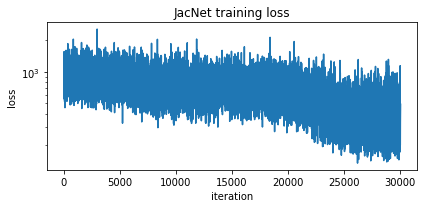

In [5]:
opt = torch.optim.Adam(jac_net.parameters(), lr=jac_config["lr"])
losses = []
print_every = max(1, jac_config["iters"] // 20)
for i in range(jac_config["iters"]):
    idx = torch.randint(0, X_target.shape[0], (jac_config["batch"],))
    loss = jac_loss(X_target[idx])
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if i % print_every == 0:
        print(f"iter {i:6d}  loss={loss.item():.4f}")
jac_net.eval()
print("Training done.")

plt.figure(figsize=(6, 3))
plt.semilogy(losses)
plt.xlabel("iteration"); plt.ylabel("loss"); plt.title("JacNet training loss")
plt.tight_layout(); plt.show()

## Sanity check against autograd ground truth

In [6]:
N_eval = 100
torch.manual_seed(99)
x0_eval = X_target[torch.randint(0, X_target.shape[0], (N_eval,))]

for tv in [0.02, 0.05, 0.1, 0.2, 0.5]:
    t_s = torch.tensor(float(tv), device=device)
    s2_v = sigma2(t_s)
    sig_t = s2_v.sqrt()
    eps_e = torch.randn_like(x0_eval)
    x_t = alpha_bar(t_s).sqrt() * x0_eval + sig_t * eps_e

    fn = lambda x: score_net(x.unsqueeze(0), t_s.view(1)).squeeze(0)
    jacs_auto = torch.stack([torch_jacobian(fn, x.clone()).detach() for x in x_t])
    J_auto = (-1.0 / sig_t) * jacs_auto

    with torch.no_grad():
        J_jac = jac_net_symmetric(x_t, t_s.expand(N_eval)) / s2_v

    frob_err = (J_jac - J_auto).norm(dim=(-2, -1)).mean().item()
    frob_scale = J_auto.norm(dim=(-2, -1)).mean().item()
    print(f"t={tv:.3f}  JacNet frob err={frob_err:.3f}  (autograd scale={frob_scale:.3f}, relerr={frob_err/frob_scale:.2f})")

t=0.020  JacNet frob err=72.135  (autograd scale=331.374, relerr=0.22)
t=0.050  JacNet frob err=13.181  (autograd scale=66.368, relerr=0.20)
t=0.100  JacNet frob err=5.795  (autograd scale=18.445, relerr=0.31)
t=0.200  JacNet frob err=1.918  (autograd scale=5.421, relerr=0.35)
t=0.500  JacNet frob err=0.571  (autograd scale=2.103, relerr=0.27)


In [7]:
torch.save({
    "jac_net_state": jac_net.state_dict(),
    "jac_config": jac_config,
}, f"{CKPT_DIR}/jacnet.pt")
print(f"Saved {CKPT_DIR}/jacnet.pt")

Saved checkpoints/n2_N5/jacnet.pt
